In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# File Reading
file_path = '/content/GS668 Assignment -2 data.txt'
with open(file_path, 'r') as f:
    my_data = np.array([float(line.strip()) for line in f if line.strip()])


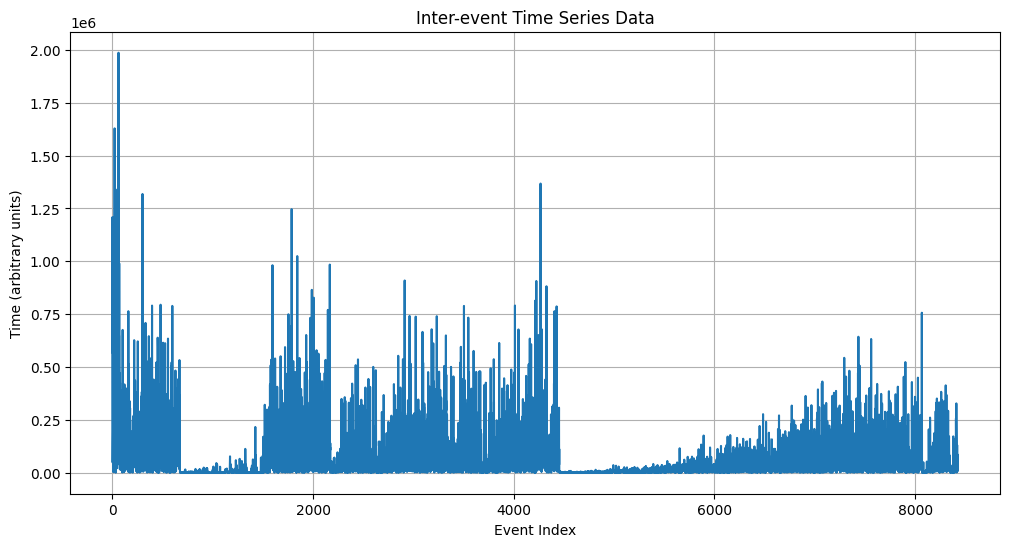

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(my_data)
plt.title('Inter-event Time Series Data')
plt.xlabel('Event Index')
plt.ylabel('Time (arbitrary units)')
plt.grid(True)
plt.show()

In [ ]:
# Setup Variables
ts = np.asarray(my_data)
n = len(ts)
P = np.arange(3, int(np.log2(n/2)) + 1)
k_vals = 2**P

rs_vals = []
valid_k = []

In [ ]:

# R/S Analysis Loop
for k in k_vals:
    num_blocks = n // k
    block_rs = []
    for i in range(num_blocks):
        block = ts[i*k : (i+1)*k]
        s = np.std(block)  # Standard deviation Calculation
        if s == 0: continue

        mean_adj = block - np.mean(block)
        cum_sum = np.cumsum(mean_adj)
        r = np.max(cum_sum) - np.min(cum_sum)  #Range calculation
        block_rs.append(r / s)           #R/S

    if block_rs:
        rs_vals.append(np.mean(block_rs))
        valid_k.append(k)

In [ ]:
# Regression and Result
log_k = np.log10(valid_k)
log_rs = np.log10(rs_vals)
H, c = np.polyfit(log_k, log_rs, 1)

print(f"Hurst Exponent (H): {H:.4f}")

Hurst Exponent (H): 0.9011


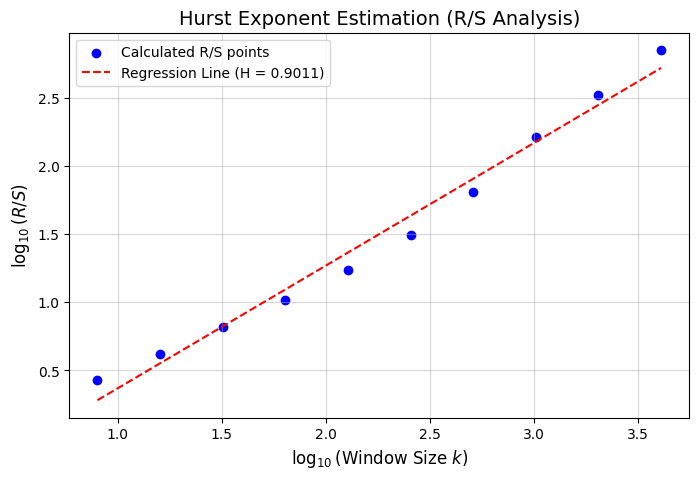

In [ ]:
# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(log_k, log_rs, color='blue', label='Calculated R/S points')
plt.plot(log_k, H * log_k + c, color='red', linestyle='--', label=f'Regression Line (H = {H:.4f})')
plt.title('Hurst Exponent Estimation (R/S Analysis)', fontsize=14)
plt.xlabel(r'$\log_{10}(\text{Window Size } k)$', fontsize=12)
plt.ylabel(r'$\log_{10}(R/S)$', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()


**Interpretation**

A Hurst Exponent (H) of **0.9011** indicates the following:

**Strong Persistence/Long-Term Memory:** Since H is significantly greater than 0.5 (and close to 1), it suggests that inter-event time series data exhibits strong long-term positive autocorrelation. This means that past values have a persistent effect on future values, and a high value is likely to be followed by another high value, and a low value by another low value.
.

In the context of **inter-event time series data**, a high Hurst Exponent means that long periods of short inter-event times (events happening rapidly) are likely to be followed by more short inter-event times, and long periods of long inter-event times (events happening slowly) are likely to be followed by more long inter-event times.